# PIVOT TABLES AND PIVOT CHARTS
### A Comprehensive Reference and Teaching Notebook

**Kajola Gbenga**
Prepared for Data Analytics and Business Intelligence Training

---

This notebook combines the full written reference guide with **live, runnable code** that mirrors every Excel pivot table concept in Python (pandas + matplotlib). Each concept section is followed by a hands-on code cell using a Nigerian retail sales dataset, so learners see the Excel logic and the equivalent code side by side.

**How to use this notebook in class:** run the setup cell first, then work top to bottom. Every code cell can be re-run after learners tweak the data or the field choices, exactly like dragging a new field in Excel.

## 1. Introduction to Pivot Tables

A pivot table is a data summarization tool found in spreadsheet software such as Microsoft Excel and Google Sheets. It takes rows of raw, transactional data and reorganizes them into a compact summary that can be sliced, grouped, and recalculated instantly without altering the source data. Instead of writing formulas to answer each new question, a pivot table lets you drag fields into place and get an answer in seconds.

The word "pivot" describes what the tool does: it rotates data between rows and columns so the same dataset can be viewed from many different angles. A single pivot table can answer "total sales by region," then be turned, with one drag, into "total sales by product category and month," without touching the underlying data.

### 1.1 Why Pivot Tables Matter

- They summarize thousands or millions of rows into a readable table in seconds.
- They require no formulas or coding knowledge to produce professional summaries.
- They are fully interactive: fields can be rearranged, filtered, and recalculated on the fly.
- They form the foundation for dashboards, management reports, and pivot charts.
- They reduce the risk of manual calculation errors common with SUMIF or manual copy-paste summaries.

### 1.2 Typical Use Cases

| Business Scenario | Pivot Table Application |
|---|---|
| Bank transaction records | Total transaction value by branch, product, and month |
| Retail sales data | Revenue and quantity sold by store, category, and salesperson |
| HR headcount data | Staff count by department, gender, and grade level |
| Loan portfolio data | Outstanding balance by loan status and risk classification |
| Survey responses | Frequency counts and averages by demographic segment |

> **In Python:** the pandas equivalent of a pivot table is `DataFrame.pivot_table()`. It performs the exact same job: group, aggregate, and reshape data, just in code instead of drag-and-drop.

## 2. Anatomy of a Pivot Table

Every pivot table is built from four functional areas. Understanding these areas is the single most important step to mastering pivot tables, because all pivot table work is really just deciding which field goes into which area.

### 2.1 The Four Areas

| Area | Purpose | Example Field |
|---|---|---|
| Filters | Restricts the entire pivot table to a subset of data without changing its layout | Region, Year |
| Rows | Creates one row per unique value; used for categories you want to see down the page | Branch Name, Product Category |
| Columns | Creates one column per unique value; used for categories you want to see across the page | Month, Gender |
| Values | Holds the numbers being summarized (sum, count, average, and so on) | Sales Amount, Quantity |

> **Tip:** A field can only be meaningfully placed in Values if it is numeric, or if you intend to Count it. Text fields placed in Values will automatically switch to a Count summary.

In `pivot_table()`, these four areas map directly onto parameters: `index=` (Rows), `columns=` (Columns), `values=` (Values), and `aggfunc=` (the summary function). Filtering is done by slicing the DataFrame before calling `pivot_table()`.

### 2.2 Source Data Requirements

1. Every column must have a single, unique header in the first row (no blank or merged headers).
2. Each row must represent one complete record (no merged cells within the data body).
3. There should be no blank rows or blank columns inside the data range.
4. Each column should contain one data type only (all dates in a date column, all numbers in a number column).
5. Where possible, the source range should be converted to an Excel Table (Ctrl+T) so the pivot table automatically expands when new rows are added. In pandas, this requirement maps to having clean, "tidy" data: one row per record, one column per variable.

## Setup: Building Our Practice Dataset

Before working through the rest of the notebook, run the cell below. It builds a realistic, messy-free transactional dataset for a Lagos-based retail chain — the same scenario used in Section 14 of the written guide — so every technique below can be demonstrated immediately.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ---- Build a synthetic Nigerian retail transactions dataset ----
branches = ["Ikeja", "Lekki", "Surulere"]
categories = ["Groceries", "Electronics", "Fashion"]
salespeople = ["Adaeze O.", "Chinedu K.", "Bimpe A.", "Tunde F.", "Ngozi E."]

dates = pd.date_range("2025-01-01", "2025-06-30", freq="D")

n_rows = 1500
df = pd.DataFrame({
    "Transaction Date": np.random.choice(dates, n_rows),
    "Branch": np.random.choice(branches, n_rows, p=[0.35, 0.4, 0.25]),
    "Product Category": np.random.choice(categories, n_rows, p=[0.4, 0.35, 0.25]),
    "Salesperson": np.random.choice(salespeople, n_rows),
    "Units Sold": np.random.randint(1, 12, n_rows),
})

# Sales Amount roughly tied to category and units, in Naira
base_price = df["Product Category"].map({"Groceries": 3500, "Electronics": 45000, "Fashion": 9000})
df["Sales Amount"] = (df["Units Sold"] * base_price * np.random.uniform(0.85, 1.15, n_rows)).round(0)
df["Cost Amount"] = (df["Sales Amount"] * np.random.uniform(0.55, 0.75, n_rows)).round(0)

df = df.sort_values("Transaction Date").reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (1500, 7)


,Transaction Date,Branch,Product Category,Salesperson,Units Sold,Sales Amount,Cost Amount
0,2025-01-01,Ikeja,Groceries,Chinedu K.,3,11374.0,7740.0
1,2025-01-01,Ikeja,Fashion,Chinedu K.,11,91071.0,63042.0
2,2025-01-01,Ikeja,Electronics,Tunde F.,10,502193.0,276801.0
3,2025-01-01,Lekki,Fashion,Tunde F.,11,85760.0,60199.0
4,2025-01-01,Surulere,Fashion,Ngozi E.,3,26020.0,17030.0
5,2025-01-01,Lekki,Groceries,Tunde F.,9,30802.0,18332.0
6,2025-01-01,Ikeja,Electronics,Tunde F.,6,277907.0,156141.0
7,2025-01-01,Lekki,Groceries,Tunde F.,9,35127.0,22921.0
8,2025-01-01,Ikeja,Groceries,Chinedu K.,3,10241.0,6503.0
9,2025-01-01,Ikeja,Electronics,Ngozi E.,6,298510.0,165742.0


## 3. Creating a Pivot Table

### 3.1 Step-by-Step (Excel)

1. Click any single cell inside the source data range or Table.
2. Go to **Insert** tab, then click **PivotTable**.
3. Confirm the data range is correct in the Create PivotTable dialog.
4. Choose the destination: New Worksheet (recommended) or Existing Worksheet.
5. Click OK. A blank pivot table shell appears alongside the PivotTable Fields pane.
6. Drag field names from the field list into the Filters, Rows, Columns, and Values boxes.
7. The pivot table updates live in the worksheet as fields are added or removed.

### 3.2 Step-by-Step (Google Sheets)

1. Select the data range.
2. Go to **Insert**, then **Pivot table**.
3. Choose New sheet or Existing sheet, then click Create.
4. In the Pivot table editor on the right, click **Add** next to Rows, Columns, Values, or Filters and choose the fields.

### 3.3 Recommended Pivot Tables

Excel offers a Recommended PivotTables option (Insert tab) that scans the data and proposes ready-made summaries. This is a fast starting point for beginners, though manually building the layout gives more control and is the better habit to develop for professional work.

### 3.4 The Python Equivalent

Below, we recreate the classic "Branch in Rows, Product Category in Columns, Sum of Sales Amount in Values" pivot table using `pd.pivot_table()`.

In [2]:
basic_pivot = pd.pivot_table(
    df,
    index="Branch",          # <-- Rows area
    columns="Product Category",  # <-- Columns area
    values="Sales Amount",   # <-- Values area
    aggfunc="sum",           # <-- Summary function
    margins=True,            # <-- adds Grand Total row/column, like Excel
    margins_name="Grand Total"
)

basic_pivot.round(0).style.format("{:,.0f}").set_caption("Sales Amount (NGN) by Branch and Product Category")

Product Category,Electronics,Fashion,Groceries,Grand Total
Branch,,,,
Ikeja,"55,152,520","6,913,938","3,987,768","66,054,226"
Lekki,"56,261,320","7,720,259","5,272,653","69,254,232"
Surulere,"31,930,152","6,176,868","2,951,272","41,058,292"
Grand Total,"143,343,992","20,811,065","12,211,693","176,366,750"


## 4. Summarizing Values

By default, Excel summarizes numeric fields with Sum and text fields with Count. This can be changed for any field placed in the Values area.

### 4.1 Available Summary Functions

| Function | What it Calculates |
|---|---|
| Sum | Total of all values in the group |
| Count | Number of records in the group (including text and blanks, depending on setting) |
| Average | Arithmetic mean of the values in the group |
| Max / Min | Largest or smallest value in the group |
| Product | Multiplies all values in the group together |
| Count Numbers | Counts only numeric entries in the group |
| StdDev / StdDevp | Sample or population standard deviation |
| Var / Varp | Sample or population variance |

To change the summary function in Excel: right-click any value cell in the pivot table, choose **Summarize Values By**, then pick the desired function.

### 4.2 Show Values As

Beyond the base summary function, each value field can also be redisplayed using a comparison calculation through **Show Values As** (right-click a value, then Show Values As):

- **% of Grand Total**: expresses each cell as a percentage of the overall total.
- **% of Column Total / % of Row Total**: expresses each cell relative to its column or row.
- **% of Parent Row / Parent Column Total**: useful for multi-level row or column groupings.
- **Running Total In**: accumulates values progressively down a field (commonly a date field).
- **Difference From / % Difference From**: compares each value to a chosen base item, such as the prior month.
- **Rank Largest to Smallest / Smallest to Largest**: ranks items within the field.
- **Index**: measures relative importance by comparing a cell to the product of its row and column totals divided by the grand total.

> **Tip:** "% of Grand Total" and "Running Total" are the two most frequently used options in financial and sales reporting, since they turn raw totals into growth and contribution insights instantly.

In pandas, the summary function is simply the `aggfunc` argument (or a list of them), and "Show Values As" calculations are done as a follow-up step on the resulting table.

In [3]:
# Multiple aggregation functions at once, like changing "Summarize Values By"
multi_agg = pd.pivot_table(
    df,
    index="Branch",
    values="Sales Amount",
    aggfunc=["sum", "mean", "count", "max", "min"]
)
multi_agg.columns = ["Sum", "Average", "Count", "Max", "Min"]
display(multi_agg.round(0).style.format("{:,.0f}").set_caption("Multiple Summary Functions by Branch"))

# "Show Values As -> % of Grand Total"
pct_of_total = (basic_pivot / basic_pivot.loc["Grand Total", "Grand Total"] * 100).round(1)
pct_of_total.style.format("{:.1f}%").set_caption("Show Values As: % of Grand Total")

,Sum,Average,Count,Max,Min
Branch,,,,,
Ikeja,"66,054,226","126,541",522,"565,441","3,059"
Lekki,"69,254,232","113,905",608,"561,508","3,060"
Surulere,"41,058,292","110,968",370,"563,749","3,127"


Product Category,Electronics,Fashion,Groceries,Grand Total
Branch,,,,
Ikeja,31.3%,3.9%,2.3%,37.5%
Lekki,31.9%,4.4%,3.0%,39.3%
Surulere,18.1%,3.5%,1.7%,23.3%
Grand Total,81.3%,11.8%,6.9%,100.0%


## 5. Grouping Data

Grouping combines individual row or column items into broader buckets, which is essential for turning granular transactional data into management-friendly summaries.

### 5.1 Grouping Dates

Right-click any date in the Rows or Columns area and choose **Group**. Excel offers Seconds, Minutes, Hours, Days, Months, Quarters, and Years, and multiple levels can be selected together (for example, Months and Years) to build a proper time hierarchy.

### 5.2 Grouping Numbers

Right-click a numeric row item and choose **Group** to bucket continuous numeric data into ranges, such as grouping customer ages into bands of 10 years, or loan amounts into bands of 500,000 Naira.

### 5.3 Grouping Text (Manual Grouping)

Select multiple row items with Ctrl+Click, right-click, and choose **Group** to combine specific text categories into a custom label, for example grouping several small product lines into an "Others" category.

> **Tip:** Grouping is destructive to the display only, not the source data. Ungroup at any time by right-clicking the grouped field and choosing Ungroup.

In pandas, date grouping is done with `pd.Grouper(freq=...)`, and numeric grouping is done with `pd.cut()`.

In [4]:
# Group dates by Month (like right-click -> Group -> Months)
monthly_pivot = pd.pivot_table(
    df,
    index=pd.Grouper(key="Transaction Date", freq="ME"),
    columns="Branch",
    values="Sales Amount",
    aggfunc="sum"
)
monthly_pivot.index = monthly_pivot.index.strftime("%B %Y")
display(monthly_pivot.round(0).style.format("{:,.0f}").set_caption("Sales Amount by Month and Branch"))

# Group a numeric field into bands, like grouping Units Sold into ranges
df["Units Band"] = pd.cut(df["Units Sold"], bins=[0, 3, 6, 9, 12], labels=["1-3", "4-6", "7-9", "10-11"])
units_band_pivot = pd.pivot_table(df, index="Units Band", values="Sales Amount", aggfunc=["sum", "count"], observed=True)
units_band_pivot.columns = ["Total Sales (NGN)", "Number of Transactions"]
units_band_pivot.style.format({"Total Sales (NGN)": "{:,.0f}"}).set_caption("Sales by Units-Sold Band")

Branch,Ikeja,Lekki,Surulere
Transaction Date,,,
January 2025,"9,803,895","11,929,500","6,543,166"
February 2025,"12,429,622","9,623,556","6,547,336"
March 2025,"10,305,282","10,777,966","6,745,726"
April 2025,"11,203,101","11,472,000","7,224,438"
May 2025,"9,809,879","13,661,788","8,369,184"
June 2025,"12,502,447","11,789,422","5,628,442"


,Total Sales (NGN),Number of Transactions
Units Band,,
1-3,"18,315,726",426
4-6,"41,988,163",401
7-9,"64,305,811",396
10-11,"51,757,050",277


## 6. Sorting, Filtering, Slicers, and Timelines

### 6.1 Sorting

Pivot table rows and columns can be sorted alphabetically, or by the values themselves (for example, sorting branches from highest to lowest sales) using the sort arrows on the field headers or the Sort option in the right-click menu.

### 6.2 Filtering

- **Report Filters**: fields dropped into the Filters area create a dropdown above the pivot table that filters the entire report.
- **Label Filters**: filter row or column items by text conditions (begins with, contains, and so on).
- **Value Filters**: filter row or column items based on their summarized value (for example, show only branches with sales above 10 million Naira).

### 6.3 Slicers

Slicers are visual, button-style filter panels, inserted from **Insert → Slicer**. Slicers are especially valuable on dashboards because they let non-technical users filter a report by clicking a button rather than opening a dropdown menu, and one slicer can be connected to multiple pivot tables and pivot charts at once through Report Connections.

### 6.4 Timelines

A Timeline is a specialized slicer for date fields, inserted from **PivotTable Analyze → Insert Timeline**. It provides a horizontal scrollable band for filtering by day, month, quarter, or year.

> In pandas, sorting is `.sort_values()`, a Report Filter is simply slicing the DataFrame before pivoting, and a Slicer's interactivity can be recreated in a notebook with `ipywidgets` dropdowns.

In [5]:
# Sorting: rank branches from highest to lowest total sales
sorted_pivot = basic_pivot.drop("Grand Total").drop(columns="Grand Total").sum(axis=1).sort_values(ascending=False)
display(sorted_pivot.round(0).map("{:,.0f}".format).to_frame("Total Sales (NGN)"))

# Report Filter equivalent: restrict to one branch before summarizing
filtered = df[df["Branch"] == "Lekki"]
filtered_pivot = pd.pivot_table(filtered, index="Product Category", values="Sales Amount", aggfunc="sum")
print("Report filtered to Branch = Lekki:")
display(filtered_pivot.round(0).style.format("{:,.0f}"))

# Optional: an interactive "slicer" using ipywidgets (works in Jupyter/Colab)
try:
    import ipywidgets as widgets
    from IPython.display import display as ip_display

    branch_dropdown = widgets.Dropdown(options=["All"] + branches, description="Branch:")

    def update_view(branch):
        data = df if branch == "All" else df[df["Branch"] == branch]
        pv = pd.pivot_table(data, index="Product Category", values="Sales Amount", aggfunc="sum")
        ip_display(pv.round(0).style.format("{:,.0f}").set_caption(f"Sales Amount — Branch: {branch}"))

    widgets.interact(update_view, branch=branch_dropdown)
except ImportError:
    print("ipywidgets not installed — install with 'pip install ipywidgets' to try the interactive slicer demo.")

,Total Sales (NGN)
Branch,
Lekki,"69,254,232"
Ikeja,"66,054,226"
Surulere,"41,058,292"


Report filtered to Branch = Lekki:


,Sales Amount
Product Category,
Electronics,"56,261,320"
Fashion,"7,720,259"
Groceries,"5,272,653"


interactive(children=(Dropdown(description='Branch:', options=('All', 'Ikeja', 'Lekki', 'Surulere'), value='Al…

## 7. Calculated Fields and Calculated Items

### 7.1 Calculated Fields

A calculated field creates a brand-new field using a formula that references other fields in the pivot table, and the result behaves like any other Values field. Created from **PivotTable Analyze → Fields, Items and Sets → Calculated Field**.

Example: a Profit Margin field could be created as Profit divided by Revenue, where Profit and Revenue are existing source fields.

### 7.2 Calculated Items

A calculated item creates a new item within an existing field using a formula that references other items in that same field. For example, within a Region field, a calculated item named "South Total" could sum the Lagos and Ogun items together.

> **Tip:** Calculated items can distort subtotals and grand totals if not used carefully, since the new item's value is added on top of the items it references. Use calculated fields where possible.

### 7.3 Limitations

- Calculated fields cannot use cell references, only field names.
- Calculated fields always use the Sum of underlying fields before applying the formula, regardless of the summary function selected for those fields elsewhere.
- Calculated fields and items are not available when the pivot table is built on the Excel Data Model or Power Pivot; DAX measures are used instead in that environment.

In pandas, a "calculated field" is simply a new column computed before pivoting, or a follow-up arithmetic operation on the pivoted result.

In [6]:
# Calculated field: Profit and Profit Margin, added to the source data before pivoting
df["Profit"] = df["Sales Amount"] - df["Cost Amount"]
df["Profit Margin %"] = (df["Profit"] / df["Sales Amount"] * 100)

margin_pivot = pd.pivot_table(
    df,
    index="Branch",
    values=["Sales Amount", "Profit"],
    aggfunc="sum"
)
margin_pivot["Profit Margin %"] = (margin_pivot["Profit"] / margin_pivot["Sales Amount"] * 100).round(1)
margin_pivot.style.format({"Sales Amount": "{:,.0f}", "Profit": "{:,.0f}", "Profit Margin %": "{:.1f}%"})

,Profit,Sales Amount,Profit Margin %
Branch,,,
Ikeja,"22,933,247","66,054,226",34.7%
Lekki,"24,124,305","69,254,232",34.8%
Surulere,"14,599,817","41,058,292",35.6%


## 8. Pivot Table Design and Layout

### 8.1 Report Layout Options

| Layout | Description |
|---|---|
| Compact Form | Default layout; all row fields stack into a single indented column |
| Outline Form | Each row field gets its own column, with subtotals above each group |
| Tabular Form | Each row field gets its own column, in a flat, database-style table — easiest to copy into other reports |

Change the layout from **PivotTable Design → Report Layout**. Tabular Form combined with "Repeat All Item Labels" is the standard choice when the pivot table output needs to be copied elsewhere or fed into a chart.

### 8.2 Subtotals and Grand Totals

- Subtotals can be shown at the top or bottom of each group, or turned off entirely, from the Design tab.
- Grand Totals can be toggled independently for rows and columns from **Design → Grand Totals**.

### 8.3 Blank Rows and Banded Rows

**Design → Blank Rows** can insert a blank line after each group for readability. Banded Rows and Banded Columns add alternating shading, and PivotTable Styles offers a gallery of ready-made formatting themes.

### 8.4 Handling Blank Cells and Errors

**PivotTable Options → Layout & Format** allows a custom value to be shown for empty cells and for error values, which keeps reports client-ready instead of showing raw blanks or #DIV/0! errors.

> In pandas, the "tabular form" is the natural shape of a DataFrame with `reset_index()`, and blank/error handling is done with `.fillna()` and `.replace()`.

## 9. Refreshing and Maintaining Pivot Tables

A pivot table is a snapshot; it does not update automatically when the source data changes.

### 9.1 Refreshing

- **Manual refresh**: right-click the pivot table and choose Refresh, or PivotTable Analyze → Refresh.
- **Refresh All**: Data tab → Refresh All updates every pivot table and connection in the workbook at once.
- **Refresh on Open**: PivotTable Options → Data tab, tick "Refresh data when opening the file."

### 9.2 Preserving Layout When the Source Grows

If the source range was converted into an Excel Table before the pivot table was created, new rows added to that table are automatically included the next time the pivot table is refreshed.

### 9.3 Common Refresh Issues

| Symptom | Likely Cause | Fix |
|---|---|---|
| New rows missing after refresh | Source range is a plain range, not a Table | Convert source to a Table, or update the range in Change Data Source |
| Field List missing a new column | New column was added outside the original source range | Change Data Source to include the new column, then refresh |
| "Reference is not valid" error | Source sheet or file was renamed, moved, or deleted | Reset Change Data Source to the corrected source location |

> In pandas, there is no "refresh" step — simply re-run the cell that builds `df` and every pivot table cell below it, in order.

## 10. The GETPIVOTDATA Function

`GETPIVOTDATA` retrieves a specific value from a pivot table using field and item names instead of a plain cell reference, which keeps the formula accurate even if the pivot table's layout changes.

**Syntax:** `GETPIVOTDATA(data_field, pivot_table, [field1, item1], [field2, item2], ...)`

**Example:** `GETPIVOTDATA("Sales Amount", $A$3, "Branch", "Ikeja", "Month", "January")` returns the January sales figure for the Ikeja branch, regardless of where that intersection currently sits inside the pivot table.

> **Tip:** GETPIVOTDATA is generated automatically when you click into a pivot table cell while typing a formula. To disable this, go to PivotTable Analyze → Options → Generate GetPivotData.

The pandas equivalent is `.loc[]` on the pivoted result, which looks up by row/column label instead of by position.

In [7]:
# GETPIVOTDATA equivalent: look up one specific intersection by label
ikeja_electronics = basic_pivot.loc["Ikeja", "Electronics"]
print(f"Sales Amount for Ikeja / Electronics: NGN {ikeja_electronics:,.0f}")

Sales Amount for Ikeja / Electronics: NGN 55,152,520


## 11. Pivot Charts

A pivot chart is a chart built directly from a pivot table (or the Data Model) that stays fully interactive: filtering, sorting, or rearranging the underlying pivot table automatically updates the chart, and the chart carries its own field buttons for filtering directly on the chart itself.

### 11.1 Creating a Pivot Chart

1. Click inside an existing pivot table.
2. Go to **PivotTable Analyze → PivotChart**.
3. Choose a chart type in the Insert Chart dialog and click OK.
4. The pivot chart appears with interactive field buttons; use these, or the linked pivot table, to filter and rearrange the view.

### 11.2 Suitable Chart Types

| Chart Type | Best For |
|---|---|
| Clustered/Stacked Column | Comparing totals across categories, or showing composition within categories over time |
| Line Chart | Showing trends over a continuous time field such as months or years |
| Bar Chart | Comparing categories with long labels, read more easily left to right |
| Pie / Doughnut Chart | Showing proportion of a whole for a single field with a small number of categories |
| Combo Chart | Comparing two measures with different scales, such as Revenue (columns) and Growth Percent (line) |

### 11.3 Key Differences from Regular Charts

- Pivot charts inherit interactive field buttons for Filters, Legend (Series), and Axis (Categories) directly on the chart canvas.
- Certain chart types available for normal charts, such as XY Scatter and Stock, are not available for pivot charts.
- Moving a pivot chart to its own Chart Sheet is common for dashboard or presentation purposes.

### 11.4 Cleaning Up Pivot Charts for Presentation

1. Hide the interactive field buttons for a cleaner look.
2. Apply a clear, descriptive chart title.
3. Use consistent, brand-appropriate colors rather than the default Excel palette for client-facing reports.
4. Turn off gridlines and simplify data labels so the chart is not visually cluttered.

> **Tip:** For dashboards, build the pivot table on a hidden or separate calculation sheet, then place only the pivot chart and slicers on the visible dashboard sheet.

Below, we build a clustered column pivot chart directly from `basic_pivot`, matching what "Insert PivotChart" would do in Excel.

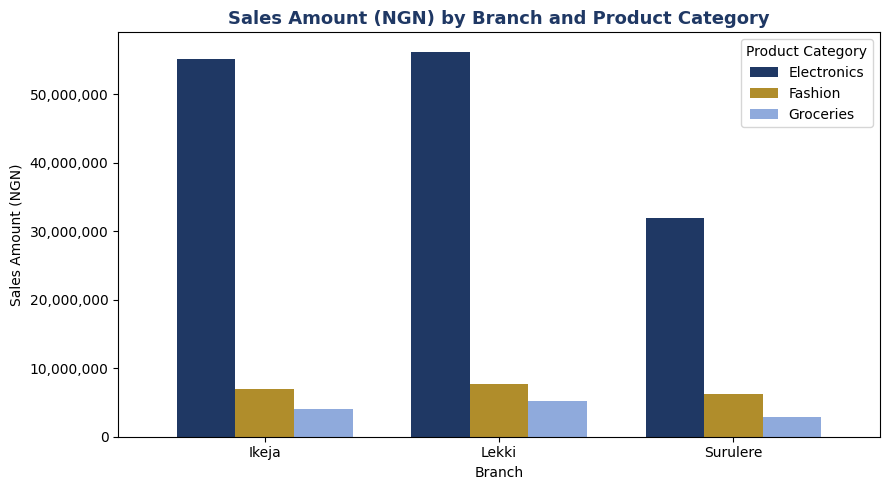

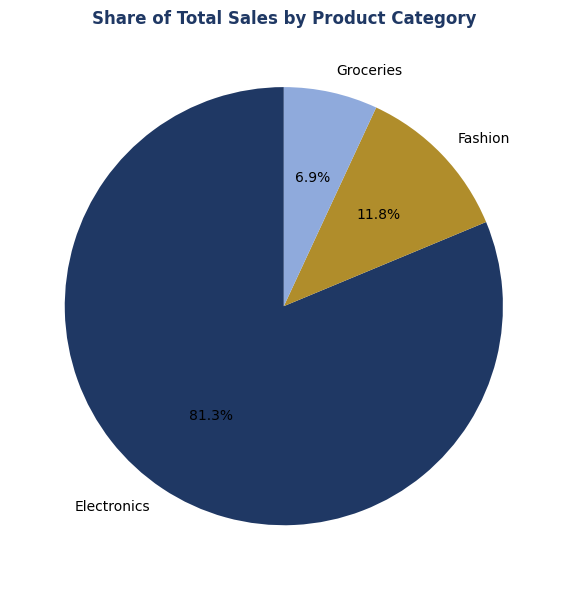

In [8]:
chart_data = basic_pivot.drop("Grand Total").drop(columns="Grand Total")

ax = chart_data.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#1F3864", "#B08D2B", "#8FAADC"],
    width=0.75
)
ax.set_title("Sales Amount (NGN) by Branch and Product Category", fontsize=13, fontweight="bold", color="#1F3864")
ax.set_xlabel("Branch")
ax.set_ylabel("Sales Amount (NGN)")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:,.0f}")
plt.xticks(rotation=0)
plt.legend(title="Product Category")
plt.tight_layout()
plt.show()

# A pie chart pivot equivalent: proportion of total sales by category
category_totals = df.groupby("Product Category")["Sales Amount"].sum()
plt.figure(figsize=(6, 6))
plt.pie(category_totals, labels=category_totals.index, autopct="%1.1f%%",
        colors=["#1F3864", "#B08D2B", "#8FAADC"], startangle=90)
plt.title("Share of Total Sales by Product Category", fontweight="bold", color="#1F3864")
plt.tight_layout()
plt.show()

## 12. Advanced Pivot Table Techniques

### 12.1 The Data Model and Relationships

Ticking "Add this data to the Data Model" in the Create PivotTable dialog allows a pivot table to be built from multiple related tables at once, joined by common key fields, without first merging them with VLOOKUP or XLOOKUP. This is the entry point into Power Pivot and DAX measures.

### 12.2 Power Pivot and DAX Measures

When working within the Data Model, DAX measures replace calculated fields. A measure such as `Total Sales := SUM(Sales[Amount])` behaves like a calculated field but supports far more advanced logic, including time intelligence functions such as year-to-date and prior-period comparisons.

### 12.3 Multiple Consolidation Ranges

An older but still useful technique for combining several separate tables with the same structure (for example, monthly sales sheets) into a single pivot table, accessed through the PivotTable and PivotChart Wizard.

### 12.4 Pivot Tables from External Data

Pivot tables can be connected to external sources including Power Query queries, SQL Server, Access databases, and text or CSV files through the Data tab.

> In pandas, the "Data Model relationship" is `pd.merge()` — joining two DataFrames on a common key before pivoting.

In [9]:
# Data Model equivalent: a second related table, joined before pivoting
salesperson_info = pd.DataFrame({
    "Salesperson": salespeople,
    "Years of Experience": [4, 7, 2, 9, 5],
    "Team": ["Retail A", "Retail B", "Retail A", "Retail B", "Retail A"],
})

merged = df.merge(salesperson_info, on="Salesperson", how="left")

team_pivot = pd.pivot_table(merged, index="Team", values="Sales Amount", aggfunc=["sum", "mean"])
team_pivot.columns = ["Total Sales (NGN)", "Average Sale (NGN)"]
team_pivot.style.format("{:,.0f}").set_caption("Sales by Sales Team (joined from a related table)")

,Total Sales (NGN),Average Sale (NGN)
Team,,
Retail A,"103,868,629","119,115"
Retail B,"72,498,121","115,443"


## 13. Common Errors and Troubleshooting

| Problem | Cause | Solution |
|---|---|---|
| Numbers show as Count instead of Sum | Source column contains at least one blank or text entry | Clean the source column so every cell is a true number, then refresh |
| "Field name is not valid" when creating a calculated field | Blank column header in the source data | Add a header to every column in the source range |
| Pivot table will not group dates | Date column contains text dates or mixed data types | Convert the column using DATEVALUE or Text to Columns, then rebuild |
| Grand Total looks wrong after adding a calculated item | Calculated item value is included in the total alongside items it references | Use a calculated field instead, or exclude the source items from the total |
| Pivot table "loses" formatting after refresh | "Autofit column widths" or "Preserve cell formatting" settings | Adjust these in PivotTable Options, Layout & Format tab |
| Cannot group selected items | Items belong to more than one field, or the field is part of the Data Model | Group from a single, non-Data-Model field, or use Power Query first |

**Python equivalents to watch for:** a column showing as `object` dtype when it should be numeric (use `pd.to_numeric()`), a date column stored as text (use `pd.to_datetime()`), and `NaN` values appearing after a `pivot_table()` where a Branch/Category combination has no data (use `fill_value=0`).

## 14. Worked Example: Nigerian Retail Sales — Full Walkthrough

Consider a raw transactional dataset from a Lagos-based retail chain with columns: Transaction Date, Branch, Product Category, Salesperson, Units Sold, and Sales Amount (Naira) — exactly the dataset built in the Setup section above.

Building a pivot table with Branch in Rows, Product Category in Columns, and Sum of Sales Amount in Values instantly produces a cross-tabulated summary showing which branch sells which category best, something that would otherwise require multiple SUMIFS formulas.

Adding Transaction Date to the Filters area and grouping it by Month and Quarter allows the same report to be viewed for any period with a single dropdown selection. Placing a slicer for Salesperson beside the report, and connecting it to a matching pivot chart, produces an interactive one-page sales performance dashboard that a branch manager can filter without needing any Excel training.

The cell below reproduces this entire mini-dashboard end to end: a filtered, quarter-grouped pivot table plus its matching pivot chart, exactly as described in the guide.

Quarterly Sales Dashboard — Branch x Quarter (NGN)


Quarter,2025Q1,2025Q2,Grand Total
Branch,,,
Ikeja,"32,538,799","33,515,427","66,054,226"
Lekki,"32,331,022","36,923,210","69,254,232"
Surulere,"19,836,228","21,222,064","41,058,292"
Grand Total,"84,706,049","91,660,701","176,366,750"


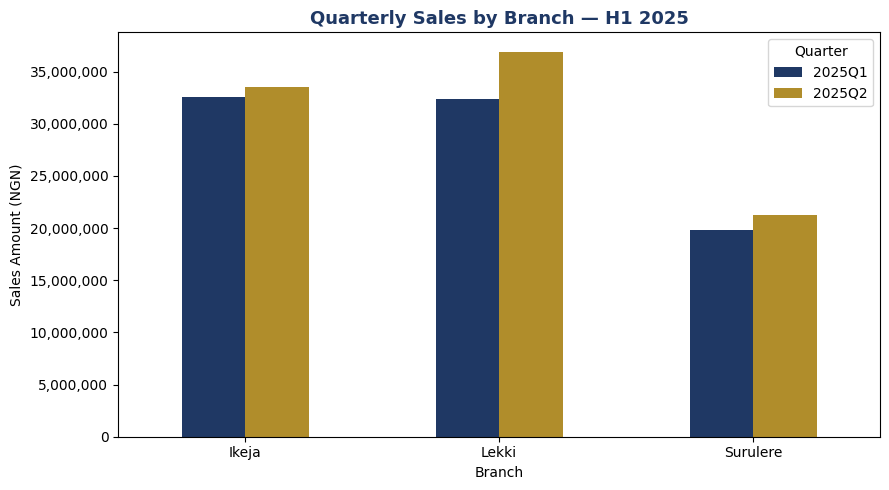

In [10]:
# Full worked example: quarterly, branch-level dashboard for H1 2025
dashboard_data = df.copy()
dashboard_data["Quarter"] = dashboard_data["Transaction Date"].dt.to_period("Q").astype(str)

quarterly_pivot = pd.pivot_table(
    dashboard_data,
    index="Branch",
    columns="Quarter",
    values="Sales Amount",
    aggfunc="sum",
    margins=True,
    margins_name="Grand Total",
    fill_value=0
)

print("Quarterly Sales Dashboard — Branch x Quarter (NGN)")
display(quarterly_pivot.round(0).style.format("{:,.0f}"))

chart_data = quarterly_pivot.drop("Grand Total").drop(columns="Grand Total")
ax = chart_data.plot(kind="bar", figsize=(9, 5), color=["#1F3864", "#B08D2B"])
ax.set_title("Quarterly Sales by Branch — H1 2025", fontsize=13, fontweight="bold", color="#1F3864")
ax.set_ylabel("Sales Amount (NGN)")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:,.0f}")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 15. Best Practices Checklist

- Always start from clean, tabular source data, ideally converted to an Excel Table (or a tidy DataFrame in pandas).
- Build the pivot table on a separate sheet from the raw data.
- Use Tabular Form with repeated item labels when the output needs to be reused elsewhere.
- Rename generic field headings such as "Sum of Sales Amount" to plain business language.
- Group dates at the appropriate level (Month, Quarter, Year) rather than leaving every single date as a separate row.
- Use slicers and timelines instead of multiple report filters when building dashboards for non-technical users.
- Set PivotTable Options to refresh automatically on file open where the source data changes frequently.
- Hide field buttons and apply consistent formatting before sharing a pivot chart externally.
- Document any calculated fields or items directly in the workbook, since their formulas are not visible on the sheet itself.
- Test the pivot table and chart after every refresh to confirm new data has been captured correctly.

## 16. Quick Reference Summary

### Excel / Google Sheets

| Task | Shortcut / Location |
|---|---|
| Insert pivot table | Insert tab, then PivotTable |
| Insert pivot chart | PivotTable Analyze tab, then PivotChart |
| Refresh pivot table | Right-click, then Refresh, or Alt+F5 |
| Refresh all pivot tables | Data tab, then Refresh All, or Ctrl+Alt+F5 |
| Group selected items | Right-click selection, then Group |
| Insert slicer | PivotTable Analyze, then Insert Slicer |
| Insert timeline | PivotTable Analyze, then Insert Timeline |
| Change summary function | Right-click value cell, then Summarize Values By |
| Show Values As | Right-click value cell, then Show Values As |
| Create calculated field | PivotTable Analyze, Fields Items and Sets, Calculated Field |
| Change report layout | Design tab, then Report Layout |
| Change data source range | PivotTable Analyze, then Change Data Source |

### Python / pandas

| Task | Code |
|---|---|
| Create a pivot table | `pd.pivot_table(df, index=, columns=, values=, aggfunc=)` |
| Add grand totals | `margins=True, margins_name="Grand Total"` |
| Change summary function | `aggfunc="mean"` or `aggfunc=["sum","mean","count"]` |
| Group dates | `pd.Grouper(key="Date", freq="ME")` inside `index=` |
| Group numbers into bands | `pd.cut(df["col"], bins=[...])` |
| Filter before pivoting | `df[df["Branch"] == "Lekki"]` |
| Sort a pivot result | `.sort_values(ascending=False)` |
| Look up one value (GETPIVOTDATA) | `pivot.loc["Row", "Column"]` |
| Fill missing combinations | `fill_value=0` |
| Build a pivot chart | `.plot(kind="bar")` on the pivoted DataFrame |
| Join related tables (Data Model) | `df.merge(other_df, on="key")` |

---

## Closing Note

Pivot tables and pivot charts remain among the highest-leverage tools in the entire analytics toolkit: a few minutes learning the Rows, Columns, Values, and Filters framework unlocks the ability to summarize almost any dataset, whether in Excel or in pandas. Mastery comes from practice on real, messy data, so learners are encouraged to swap in their own dataset — bank transactions, HR headcount, or survey data — and rebuild every example in this notebook before moving on to Power Pivot, DAX, or advanced pandas groupby techniques.